# Library Import

In [25]:
celebA = False
loss_type = "histogram"

In [26]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import random
from PIL import Image 
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F

# Face Dataset

In [27]:
# Showing images
def imshow(img, text=None):
    npimg = img.numpy()
    plt.axis("off")
    if text:
        plt.text(75, 8, text, style='italic',fontweight='bold',
            bbox={'facecolor':'white', 'alpha':0.8, 'pad':10})
        
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()    

# Plotting data
def show_plot(iteration,loss):
    plt.plot(iteration,loss)
    plt.show()

In [28]:
class SiameseNetworkDataset(Dataset):
    def __init__(self, imageFolderDataset, transform=None):
        self.imageFolderDataset = imageFolderDataset    
        self.transform = transform
        
    def __getitem__(self, index):
        img0_tuple = random.choice(self.imageFolderDataset.imgs)

        # We need approximately 50% of images to be in the same class
        should_get_same_class = random.randint(0, 1) 
        if should_get_same_class:
            while True:
                # Look until the same class image is found
                img1_tuple = random.choice(self.imageFolderDataset.imgs) 
                if img0_tuple[1] == img1_tuple[1]:
                    break
        else:
            while True:
                # Look until a different class image is found
                img1_tuple = random.choice(self.imageFolderDataset.imgs) 
                if img0_tuple[1] != img1_tuple[1]:
                    break

        img0 = Image.open(img0_tuple[0])
        img1 = Image.open(img1_tuple[0])

        # Convert to RGB if image is in another format (e.g., RGBA)
        if img0.mode != 'RGB':
            img0 = img0.convert('RGB')
        if img1.mode != 'RGB':
            img1 = img1.convert('RGB')

        if self.transform is not None:
            img0 = self.transform(img0)
            img1 = self.transform(img1)
        
        # Return the images, similarity label (0 or 1), and the original class labels
        return img0, img1, torch.from_numpy(np.array([int(img1_tuple[1] != img0_tuple[1])], dtype=np.float32)), img0_tuple[1], img1_tuple[1]
    
    def __len__(self):
        return len(self.imageFolderDataset.imgs)

In [29]:

## Custom augmentations
class CenterZoom:
    def __init__(self, zoom_factor=1.5):
        self.zoom_factor = zoom_factor

    def __call__(self, img):
        width, height = img.size
        new_width = int(width / self.zoom_factor)
        new_height = int(height / self.zoom_factor)
        left = (width - new_width) // 2
        top = (height - new_height) // 2
        right = left + new_width
        bottom = top + new_height
        img = img.crop((left, top, right, bottom))
        return img.resize((width, height))
    

from PIL import Image, ImageFilter, ImageEnhance
class RandomRotate:
    def __init__(self, degrees=15):
        self.degrees = degrees

    def __call__(self, img):
        angle = random.uniform(-self.degrees, self.degrees)
        return img.rotate(angle, resample=Image.BILINEAR, expand=False)


class RandomBlur:
    def __init__(self, max_radius=2):
        self.max_radius = max_radius

    def __call__(self, img):
        radius = random.uniform(0, self.max_radius)
        return img.filter(ImageFilter.GaussianBlur(radius=radius))

class RandomNoise:
    def __init__(self, noise_level=0.05):
        self.noise_level = noise_level

    def __call__(self, img):
        img_np = np.array(img) / 255.0
        noise = np.random.normal(0, self.noise_level, img_np.shape)
        noisy_img = img_np + noise
        noisy_img = np.clip(noisy_img, 0, 1)
        noisy_img = (noisy_img * 255).astype(np.uint8)
        return Image.fromarray(noisy_img)




In [30]:
if celebA:
    # Load the training dataset
    folder_dataset = datasets.ImageFolder(root="data/faces/celebA/train")

    # Resize the images and transform to tensors
    transformation = transforms.Compose([
        
       RandomRotate(degrees=5),  # Added rotation
    RandomBlur(max_radius=1.0),  # Added blur
       RandomNoise(noise_level=0.03),  # Added noise
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        CenterZoom(zoom_factor=1.5),  # Reduced from 1.5
        transforms.Resize((100,100)),
        transforms.ToTensor()
    ])

    # Initialize the network
    siamese_dataset = SiameseNetworkDataset(imageFolderDataset=folder_dataset,
                                            transform=transformation)

    train_dataloader = DataLoader(siamese_dataset, num_workers=0, batch_size=128, shuffle=True)

    # Load the training dataset
    val_folder_dataset = datasets.ImageFolder(root="data/faces/celebA/val")

    # Resize the images and transform to tensors
    val_transformation = transforms.Compose([transforms.Resize((100,100)),
                                        CenterZoom(zoom_factor=1.5),  # Reduced from 1.5
                                        transforms.ToTensor()
                                        ])

    # Initialize the network
    siamese_dataset_val = SiameseNetworkDataset(imageFolderDataset=val_folder_dataset,
                                            transform=val_transformation)

    val_dataloader = DataLoader(siamese_dataset_val, num_workers=0, batch_size=128, shuffle=True)
else:
    # Load the training dataset
    folder_dataset = datasets.ImageFolder(root="data/faces/train")

    # Resize the images and transform to tensors
    import torchvision.transforms as transforms
    from torchvision.transforms import RandomAffine, RandomPerspective, RandomGrayscale, RandomErasing


    transformation = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        #transforms.RandomApply([
        #    RandomRotate(degrees=5),
        #    RandomBlur(max_radius=1.0),
        #    RandomNoise(noise_level=0.03)
        #], p=0.8),
        #transforms.RandomApply([
        #    RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05), shear=5)
        #], p=0.5),
        #transforms.RandomPerspective(distortion_scale=0.3, p=0.3),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
        #transforms.RandomGrayscale(p=0.1),
        transforms.Resize((100, 100)),
        transforms.ToTensor(),
        transforms.RandomErasing(p=0.2, scale=(0.02, 0.1), ratio=(0.1, 2.3), value='random')
    ])

                           

    # Initialize the network
    siamese_dataset = SiameseNetworkDataset(imageFolderDataset=folder_dataset,
                                            transform=transformation)
    
     # Load the training dataset
    val_folder_dataset = datasets.ImageFolder(root="data/faces/val")

    # Resize the images and transform to tensors
    val_transformation = transforms.Compose([transforms.Resize((100,100)),
                                        transforms.ToTensor()
                                        ])

    # Initialize the network
    siamese_dataset_val = SiameseNetworkDataset(imageFolderDataset=val_folder_dataset,
                                            transform=val_transformation)

    val_dataloader = DataLoader(siamese_dataset_val, num_workers=0, batch_size=128, shuffle=True)

    train_dataloader = DataLoader(siamese_dataset, num_workers=0, batch_size=128, shuffle=True)

FileNotFoundError: [Errno 2] No such file or directory: 'data/faces/train'

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.4872136..3.8759882].


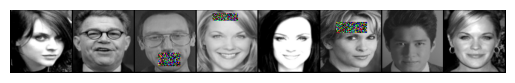

[0. 1. 1. 0.]


In [ ]:

a = DataLoader(siamese_dataset, num_workers=0, batch_size=4, shuffle=True)
# Extract one batch
example_batch = next(iter(a))

# Example batch is a list containing 2x8 images, indexes 0 and 1, an also the label
# If the label is 1, it means that it is not the same person, label is 0, same person in both images
concatenated = torch.cat((example_batch[0], example_batch[1]),0)

imshow(torchvision.utils.make_grid(concatenated))
print(example_batch[2].numpy().reshape(-1))

# Network

In [ ]:
"""#create the Siamese Neural Network
class SiameseNetwork(nn.Module):

    def __init__(self):
        super(SiameseNetwork, self).__init__()

        # Setting up the Sequential of CNN Layers
        self.cnn1 = nn.Sequential(
            nn.Conv2d(1, 96, kernel_size=11,stride=4),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2),
            
            nn.Conv2d(96, 256, kernel_size=5, stride=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, stride=2),

            nn.Conv2d(256, 384, kernel_size=3,stride=1),
            nn.ReLU(inplace=True)
        )

        # Setting up the Fully Connected Layers
        self.fc1 = nn.Sequential(
            nn.Linear(384, 1024),
            nn.ReLU(inplace=True),
            
            nn.Linear(1024, 256),
            

        )
        
    def forward_once(self, x):
        # This function will be called for both images
        # Its output is used to determine the similiarity
        output = self.cnn1(x)
        output = output.view(output.size()[0], -1)
        output = self.fc1(output)
        return output

    def forward(self, input1, input2):
        # In this function we pass in both images and obtain both vectors
        # which are returned
        output1 = self.forward_once(input1)
        output2 = self.forward_once(input2)

        return output1, output2
"""

'#create the Siamese Neural Network\nclass SiameseNetwork(nn.Module):\n\n    def __init__(self):\n        super(SiameseNetwork, self).__init__()\n\n        # Setting up the Sequential of CNN Layers\n        self.cnn1 = nn.Sequential(\n            nn.Conv2d(1, 96, kernel_size=11,stride=4),\n            nn.ReLU(inplace=True),\n            nn.MaxPool2d(3, stride=2),\n\n            nn.Conv2d(96, 256, kernel_size=5, stride=1),\n            nn.ReLU(inplace=True),\n            nn.MaxPool2d(2, stride=2),\n\n            nn.Conv2d(256, 384, kernel_size=3,stride=1),\n            nn.ReLU(inplace=True)\n        )\n\n        # Setting up the Fully Connected Layers\n        self.fc1 = nn.Sequential(\n            nn.Linear(384, 1024),\n            nn.ReLU(inplace=True),\n\n            nn.Linear(1024, 256),\n\n\n        )\n\n    def forward_once(self, x):\n        # This function will be called for both images\n        # Its output is used to determine the similiarity\n        output = self.cnn1(x)\n  

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import resnet18

class SiameseNetwork(nn.Module):
    def __init__(self):
        super(SiameseNetwork, self).__init__()
        
        # Using ResNet18 as the backbone with 3-channel input
        self.cnn1 = resnet18(pretrained=True)  # Using pretrained weights
        
        # Remove the original fully connected layer of ResNet18
        self.cnn1.fc = nn.Identity()
        
        # Setting up your custom Fully Connected Layers
        # ResNet18 outputs 512 features
        self.fc1 = nn.Sequential(
            nn.Linear(512, 1024),
            nn.ReLU(inplace=True),
            nn.Linear(1024, 256),
        )

        self.bn = nn.BatchNorm1d(256)
        
    def forward_once(self, x):
        # Forward pass through ResNet18
        output = self.cnn1(x)
        # Flatten the output
        output = output.view(output.size()[0], -1)
        # Forward pass through custom FC layers
        output = self.fc1(output)
        output = self.bn(output)
        return output
    
    def forward(self, input1, input2):
        # Forward pass for both inputs
        output1 = self.forward_once(input1)
        output2 = self.forward_once(input2)
        return output1, output2

In [ ]:
import pytorch_metric_learning.losses as losses
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = SiameseNetwork().to(DEVICE)


if loss_type == "histogram":
    criterion = losses.CircleLoss(m = 0.25, gamma = 256).to(DEVICE)
elif loss_type == "ms":
    criterion = losses.MultiSimilarityLoss().to(DEVICE)


In [ ]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if using multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Set seed before any operations
set_seed(42)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, datasets
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
import numpy as np
import mlflow
from colorama import Fore, Style, init
from tqdm.auto import tqdm
import warnings

# Initialize colorama
init()

# Constants and setup
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
warnings.filterwarnings("ignore")

# Define your SiameseNetwork and SiameseNetworkDataset classes here
# (Assuming these are defined elsewhere in your code)

# Transformation pipeline
transformation = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.Resize((100, 100)),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1), ratio=(0.1, 2.3), value='random')
])

# Prepare the full dataset
full_folder_dataset = datasets.ImageFolder(root="data/faces/all")
full_siamese_dataset = SiameseNetworkDataset(imageFolderDataset=full_folder_dataset,
                                           transform=transformation)

# Set up K-Fold cross validation
k_folds = 5
kfold = KFold(n_splits=k_folds, shuffle=True)

# MLflow setup
experiment_name = f"{loss_type}_loss"
try:
    experiment_id = mlflow.create_experiment(experiment_name)
except:
    experiment_id = mlflow.get_experiment_by_name(experiment_name).experiment_id

mlflow.set_experiment(experiment_name)

# Training variables
best_overall_f1 = -1
best_fold_index = -1
all_fold_results = []
radians = []

for fold, (train_ids, val_ids) in enumerate(kfold.split(full_siamese_dataset)):
    print(f'\n{"="*40}')
    print(f'FOLD {fold + 1}/{k_folds}')
    print(f'{"="*40}\n')
    
    # Initialize metrics for this fold
    batch_loss_history = []
    batch_val_loss_history = []
    epoch_loss_history = []
    epoch_val_loss_history = []
    val_accuracy_history = []
    val_precision_history = []
    val_recall_history = []
    val_f1_history = []
    
    # Create subsets and dataloaders
    train_subsampler = Subset(full_siamese_dataset, train_ids)
    val_subsampler = Subset(full_siamese_dataset, val_ids)
    
    train_dataloader = DataLoader(train_subsampler, batch_size=32, shuffle=True)
    val_dataloader = DataLoader(val_subsampler, batch_size=32, shuffle=False)
    
    # Reinitialize model and optimizer for each fold
    net = SiameseNetwork().to(DEVICE)
    optimizer = optim.AdamW(net.parameters(), lr=1e-4, weight_decay=1e-4)
    
    # Early stopping variables
    best_val_loss = np.inf
    epochs_no_improve = 0
    early_stop = False
    patience = 5
    
    # MLflow tracking for this fold
    with mlflow.start_run(run_name=f"Fold_{fold}", nested=True):
        mlflow.log_param("fold", fold)
        
        NUM_EPOCHS = 60
        for epoch in range(NUM_EPOCHS):
            if early_stop:
                print(Fore.RED + f"Early stopping triggered after {epoch} epochs!")
                break

            # Training phase
            net.train()
            cum_loss = 0
            pbar = tqdm(enumerate(train_dataloader, 0), total=len(train_dataloader),
                        desc=Fore.CYAN + f"Epoch {epoch + 1}/{NUM_EPOCHS} [Training]" + Style.RESET_ALL, leave=True)

            for i, (img0, img1, label, label0, label1) in pbar:
                img0, img1, label = img0.to(DEVICE), img1.to(DEVICE), label.to(DEVICE)
                label0, label1 = label0.to(DEVICE), label1.to(DEVICE)

                optimizer.zero_grad()
                output1, output2 = net(img0, img1)

                if loss_type == "contrastive":
                    loss = criterion(output1, output2, label)
                else:
                    embeddings = torch.cat([output1, output2])
                    labels = torch.cat([label0, label1])
                    loss = criterion(embeddings, labels)

                loss.backward()
                optimizer.step()

                cum_loss += loss.item()
                batch_loss_history.append(loss.item())
                mlflow.log_metric("batch_train_loss", loss.item(), step=epoch * len(train_dataloader) + i)

                avg_train_loss = cum_loss / (i + 1)
                pbar.set_postfix({
                    'TrL': f"{avg_train_loss:.4f}",
                    'VL': f"{epoch_val_loss_history[-1]:.4f}" if epoch_val_loss_history else '--',
                    'Acc': f"{val_accuracy_history[-1]:.4f}" if val_accuracy_history else '--',
                })
            
            epoch_loss_history.append(avg_train_loss)

            # Validation phase
            net.eval()
            val_loss = 0.0
            total_samples = 0
            correct_predictions = 0
            true_positives = 0
            false_positives = 0
            false_negatives = 0
            
            # For ROC AUC calculation
            all_distances = []
            all_labels = []

            with torch.no_grad():
                for img0, img1, label, label0, label1 in val_dataloader:
                    img0, img1, label = img0.to(DEVICE), img1.to(DEVICE), label.to(DEVICE)
                    label0, label1 = label0.to(DEVICE), label1.to(DEVICE)

                    output1, output2 = net(img0, img1)
                    distances =F.cosine_similarity(output1, output2)
            
                    
                    # Store distances and labels for ROC AUC
                    all_distances.extend(distances.cpu().numpy())
                    all_labels.extend(label.cpu().numpy())
                    
                    for i in range(len(distances)):
                        euclid = distances[i].item()
                        label_pred = 0 if euclid >= 0.5 else 1
                        true_label = label[i].item()
                    
                        total_samples += 1
                        correct_predictions += (label_pred == true_label)
                    
                        if label_pred == 1:
                            if true_label == 1:
                                true_positives += 1
                            else:
                                false_positives += 1
                        elif true_label == 1:
                            false_negatives += 1

                        if loss_type == "contrastive":
                            loss = criterion(output1, output2, label)
                        else:
                            embeddings = torch.cat([output1, output2])
                            labels = torch.cat([label0, label1])
                            loss = criterion(embeddings, labels)

                    val_loss += loss.item()

            avg_val_loss = val_loss / len(val_dataloader)
            epoch_val_loss_history.append(avg_val_loss)
            
            # Calculate metrics
            val_accuracy = correct_predictions / total_samples
            val_precision = true_positives / (true_positives + false_positives + 1e-10)
            val_recall = true_positives / (true_positives + false_negatives + 1e-10)
            val_f1 = 2 * (val_precision * val_recall) / (val_precision + val_recall + 1e-10)
            
    
            
            # Update histories
            val_accuracy_history.append(val_accuracy)
            val_precision_history.append(val_precision)
            val_recall_history.append(val_recall)
            val_f1_history.append(val_f1)

            # Log metrics to MLflow
            mlflow.log_metrics({
                "epoch_train_loss": avg_train_loss,
                "epoch_val_loss": avg_val_loss,
                "val_accuracy": val_accuracy,
                "val_precision": val_precision,
                "val_recall": val_recall,
                "val_f1": val_f1,
            }, step=epoch)

            # Early stopping check
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                epochs_no_improve = 0
                torch.save(net.state_dict(), f"models_{loss_type}/best_model_fold_{fold}.pt")
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    early_stop = True

            pbar.set_postfix({
                'Train Loss': f"{avg_train_loss:.4f}",
                'Val Loss': f"{avg_val_loss:.4f}",
                'Accuracy': f"{val_accuracy:.4f}",
                'F1': f"{val_f1:.4f}",
            })
            pbar.close()

        # Store fold results
        fold_results = {
            'best_val_loss': best_val_loss,
            'best_val_f1': max(val_f1_history),
            'best_val_accuracy': max(val_accuracy_history),
            'final_epoch': epoch,
            'loss_history': epoch_loss_history,
            'val_loss_history': epoch_val_loss_history,
            'metrics_history': {
                'accuracy': val_accuracy_history,
                'f1': val_f1_history,
                'precision': val_precision_history,
                'recall': val_recall_history,
            }
        }
        all_fold_results.append(fold_results)
        
        # Track best overall model
        current_fold_best_f1 = max(val_f1_history)
        if current_fold_best_f1 > best_overall_f1:
            best_overall_f1 = current_fold_best_f1
            best_fold_index = fold
            torch.save(net.state_dict(), f"models_{loss_type}/best_model_overall.pt")
            mlflow.log_artifact(f"models_{loss_type}/best_model_overall.pt")

# After all folds complete
print("\nCross-Validation Results Summary:")
print("="*50)
for i, res in enumerate(all_fold_results):
    print(f"Fold {i}: Best Val Loss: {res['best_val_loss']:.4f}, "
          f"Best Val F1: {res['best_val_f1']:.4f}, "
          f"Best Accuracy: {res['best_val_accuracy']:.4f}")

# Calculate and log average metrics
avg_val_loss = np.mean([res['best_val_loss'] for res in all_fold_results])
avg_val_f1 = np.mean([res['best_val_f1'] for res in all_fold_results])
avg_val_acc = np.mean([res['best_val_accuracy'] for res in all_fold_results])

print(f"\nAverage across all folds: Val Loss: {avg_val_loss:.4f}, "
      f"Val F1: {avg_val_f1:.4f}, Accuracy: {avg_val_acc:.4f}")

# Log the average metrics to MLflow
with mlflow.start_run(run_name="CV_Summary"):
    mlflow.log_metrics({
        "avg_val_loss": avg_val_loss,
        "avg_val_f1": avg_val_f1,
        "avg_val_accuracy": avg_val_acc,
    })
    mlflow.log_params({
        "k_folds": k_folds,
        "optimizer": "AdamW",
        "learning_rate": 1e-4,
        "weight_decay": 1e-4
    })

print(f"\nBest model from Fold {best_fold_index} (Val F1={best_overall_f1:.4f})")


FOLD 1/5



Epoch 1/60 [Training]:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 2/60 [Training]:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 3/60 [Training]:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 4/60 [Training]:   0%|          | 0/88 [00:00<?, ?it/s]

...

Epoch 57/60 [Training]:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 58/60 [Training]:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 59/60 [Training]:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 60/60 [Training]:   0%|          | 0/88 [00:00<?, ?it/s]


Cross-Validation Results Summary:
Fold 0: Best Val Loss: 7.7008, Best Val F1: 1.0000, Best Accuracy: 1.0000
Fold 1: Best Val Loss: 5.6800, Best Val F1: 1.0000, Best Accuracy: 1.0000
Fold 2: Best Val Loss: 7.7195, Best Val F1: 1.0000, Best Accuracy: 1.0000
Fold 3: Best Val Loss: 8.0786, Best Val F1: 1.0000, Best Accuracy: 1.0000
Fold 4: Best Val Loss: 7.8867, Best Val F1: 1.0000, Best Accuracy: 1.0000

Average across all folds: Val Loss: 7.4131, Val F1: 1.0000, Accuracy: 1.0000

Best model from Fold 4 (Val F1=1.0000)


In [ ]:

# Resize the images and transform to tensors
transformation_test = transforms.Compose([transforms.Resize((100,100)),
                                     transforms.RandomHorizontalFlip(),
                                     #CenterZoom(zoom_factor=1.2),  # Reduced from 1.5
                                     transforms.ToTensor()
                                    ])

root="data/faces/test/"
folder_dataset_test = datasets.ImageFolder(root=root)
test_dataset = SiameseNetworkDataset(imageFolderDataset=folder_dataset_test,
                                        transform=transformation_test)
test_dataloader = DataLoader(test_dataset, num_workers=0, batch_size=1, shuffle=True)

✅ Average Intra-Class Distance: 10.0183
✅ Average Inter-Class Distance: 15.4117


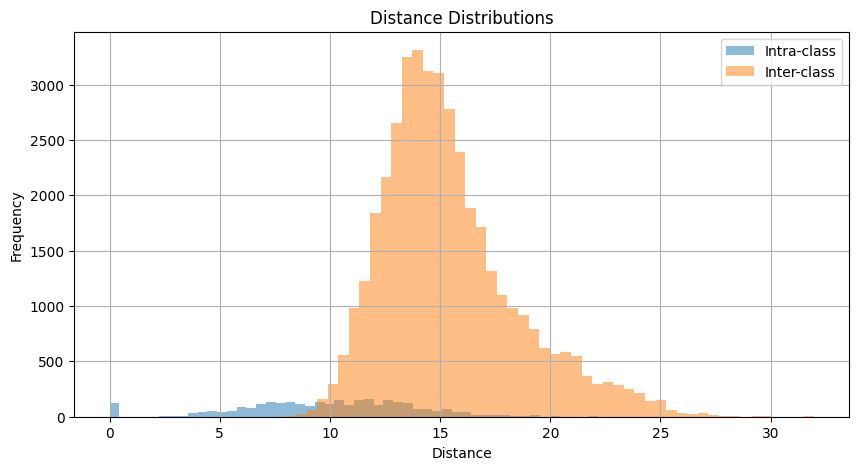

In [ ]:
from collections import defaultdict
from itertools import combinations
import torch.nn.functional as F

# Set model to evaluation mode
net.eval()

# Collect embeddings and labels from validation set
all_embeddings = []
all_labels = []

with torch.no_grad():
    for img0, img1, _, label0, label1 in test_dataloader:
        img0, img1 = img0.to(DEVICE), img1.to(DEVICE)
        label0, label1 = label0.to(DEVICE), label1.to(DEVICE)
        output1, output2 = net(img0, img1)

        all_embeddings.append(torch.cat([output1, output2]))
        all_labels.append(torch.cat([label0, label1]))

# Concatenate all embeddings and labels
all_embeddings = torch.cat(all_embeddings)  # shape: [N, D]
all_labels = torch.cat(all_labels)          # shape: [N]

# Group embeddings by class
class_to_embeddings = defaultdict(list)
for emb, label in zip(all_embeddings, all_labels):
    class_to_embeddings[label.item()].append(emb)

for key in class_to_embeddings:
    class_to_embeddings[key] = torch.stack(class_to_embeddings[key])

# Compute intra-class distances
intra_dists = []
for emb_list in class_to_embeddings.values():
    for i, j in combinations(range(len(emb_list)), 2):
        dist = F.pairwise_distance(emb_list[i].unsqueeze(0), emb_list[j].unsqueeze(0))
        intra_dists.append(dist.item())

# Compute inter-class distances
inter_dists = []
label_keys = list(class_to_embeddings.keys())
for i in range(len(label_keys)):
    for j in range(i+1, len(label_keys)):
        emb_i = class_to_embeddings[label_keys[i]]
        emb_j = class_to_embeddings[label_keys[j]]
        for e1 in emb_i:
            for e2 in emb_j:
                dist = F.pairwise_distance(e1.unsqueeze(0), e2.unsqueeze(0))
                inter_dists.append(dist.item())

# Compute statistics
avg_intra = sum(intra_dists) / len(intra_dists)
avg_inter = sum(inter_dists) / len(inter_dists)

print(f"✅ Average Intra-Class Distance: {avg_intra:.4f}")
print(f"✅ Average Inter-Class Distance: {avg_inter:.4f}")

# Optional: Visualize distributions
plt.figure(figsize=(10, 5))
plt.hist(intra_dists, bins=50, alpha=0.5, label='Intra-class')
plt.hist(inter_dists, bins=50, alpha=0.5, label='Inter-class')
plt.title("Distance Distributions")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()


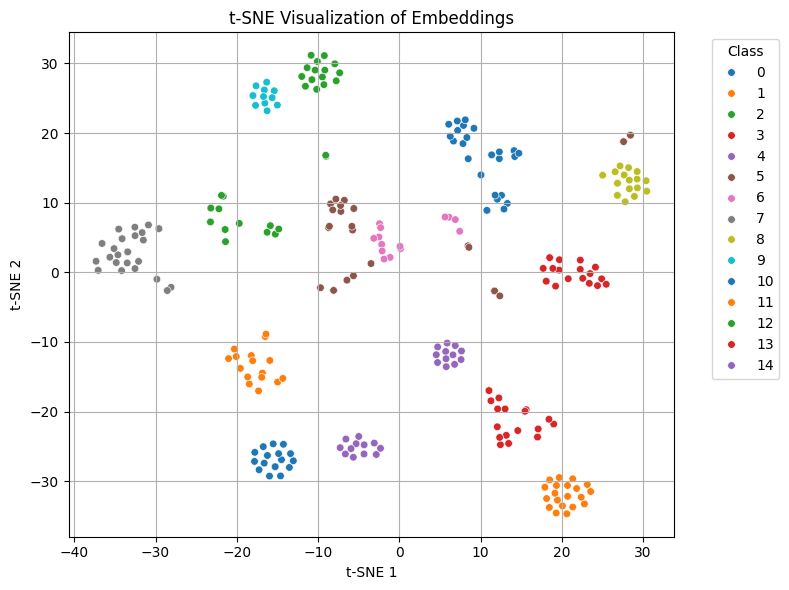

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns
# Convert tensors to NumPy arrays
X = all_embeddings.cpu().numpy()
y = all_labels.cpu().numpy()


# Dynamically adjust perplexity based on sample count
n_samples = X.shape[0]

# --- t-SNE ---
tsne = TSNE(n_components=2, max_iter=1000, perplexity=20, random_state=42, metric="cosine")
X_tsne = tsne.fit_transform(X)

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette='tab10', legend='full', s=30)
plt.title("t-SNE Visualization of Embeddings")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Class", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()


In [ ]:

# Resize the images and transform to tensors
transformation_test = transforms.Compose([transforms.Resize((100,100)),
                                     transforms.RandomHorizontalFlip(),
                                     #CenterZoom(zoom_factor=1.2),  # Reduced from 1.5
                                     transforms.ToTensor()
                                    ])

root="data/faces/test/"
folder_dataset_test = datasets.ImageFolder(root=root)
test_dataset = SiameseNetworkDataset(imageFolderDataset=folder_dataset_test,
                                        transform=transformation_test)
test_dataloader = DataLoader(test_dataset, num_workers=0, batch_size=1, shuffle=True)

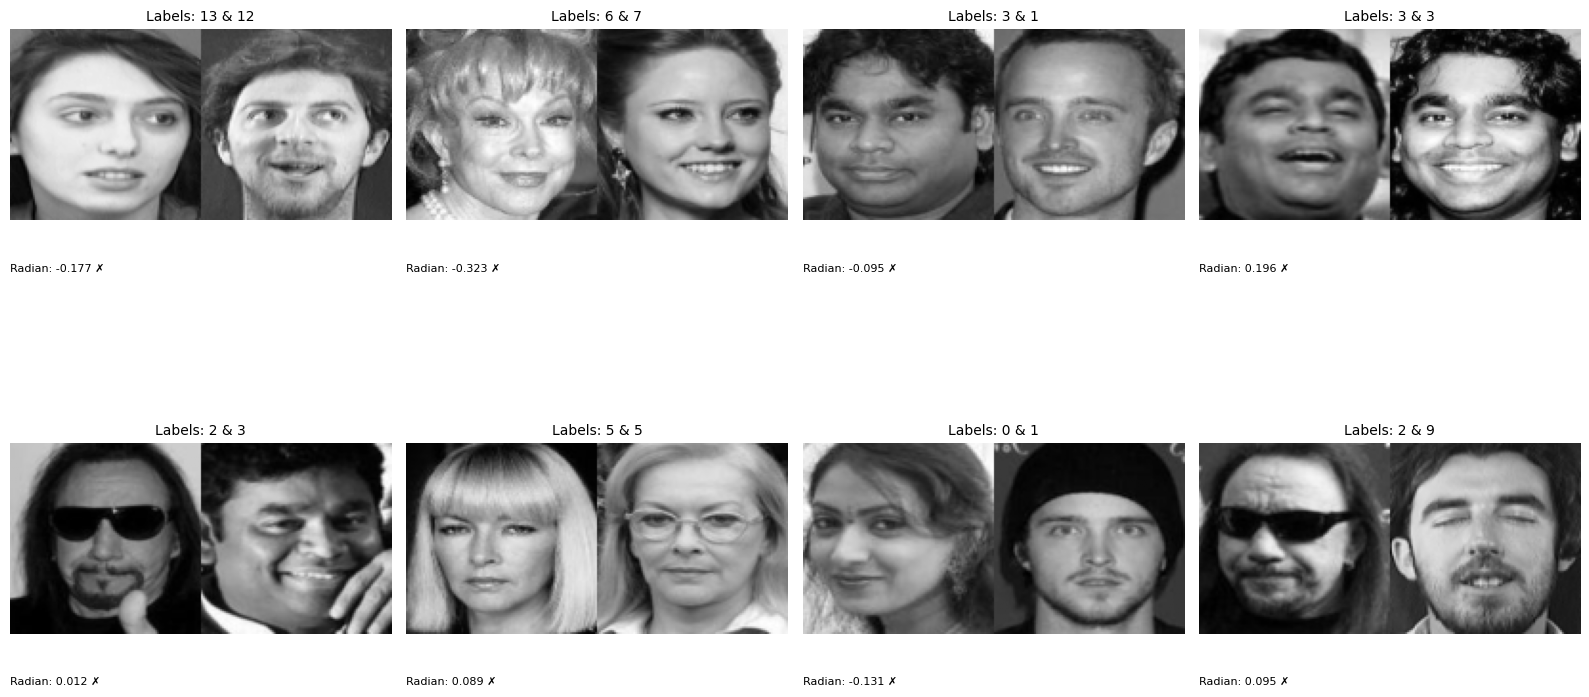

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def process_label(lbl):
    if isinstance(lbl, torch.Tensor):
        return lbl[0].cpu().item() if lbl.dim() > 0 else lbl.item()
    return lbl

def get_embeddings(model, img1, img2):
    """Get embeddings from the model for both images"""
    with torch.no_grad():
        model.eval()
        # Assuming your model takes one image at a time and returns its embedding
        emb1, emb2 = model(img1, img2)
    return emb1, emb2

def plot_samples_with_metrics(test_loader, model, n_samples=8, n_cols=4):
    pairs_imgs = []
    all_metrics = []

    for _ in range(n_samples):
        img1, img2, _, label1, label2 = next(iter(test_loader))
        lbl1, lbl2 = process_label(label1), process_label(label2)

        # Get embeddings and calculate metrics
        emb1, emb2 = get_embeddings(model, img1, img2)
        euclid = F.pairwise_distance(emb1, emb2).mean().item()
        cos_sim = F.cosine_similarity(emb1, emb2).mean().item()

        # Convert images to grayscale and concatenate
        img1_gray = img1[0].cpu().mean(dim=0, keepdim=True)
        img2_gray = img2[0].cpu().mean(dim=0, keepdim=True)
        concat_img = torch.cat((img1_gray, img2_gray), dim=2)
        pairs_imgs.append((concat_img.squeeze(0), lbl1, lbl2, euclid, cos_sim))

    # Create figure
    n_rows = (n_samples + n_cols - 1) // n_cols
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 5 * n_rows))
    if n_samples > 1:
        axs = axs.flatten()
    else:
        axs = [axs]

    for i, ax in enumerate(axs):
        if i < n_samples:
            img, lbl1, lbl2, euclid, cos_sim = pairs_imgs[i]
            
            # Display image
            ax.imshow(img.numpy(), cmap='gray')
            ax.axis('off')
            ax.set_title(f"Labels: {lbl1} & {lbl2}", fontsize=10)

            # Display metrics
            text_y = -0.15
            cos_sim_symbol = "✓" if cos_sim > 0.45 else "✗"
    
            ax.text(0, text_y - 0.12, f"Radian: {cos_sim:.3f} {cos_sim_symbol}", 
                   transform=ax.transAxes, fontsize=8)
        else:
            ax.axis('off')

    plt.tight_layout()
    plt.show()

# Example usage with your single model
plot_samples_with_metrics(test_loader=test_dataloader, model=net, n_samples=8, n_cols=4)